## Non-Linear SVM

Linear SVM separates classes with a straight line/hyperplane — but many real datasets aren't linearly separable (e.g. one class surrounds another in a circle).

**Non-linear SVM** solves this using **kernel functions**: instead of drawing a straight boundary in the original space, it maps data to a higher-dimensional space where a linear separator exists, then projects that boundary back — producing a **curved decision boundary** in the original space.

### What is a Kernel?

A kernel computes the similarity between two points **as if** they were in a higher-dimensional space — without actually transforming them (the **kernel trick**).

$$K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i) \cdot \phi(\mathbf{x}_j)$$

where $\phi$ is the implicit mapping to higher dimensions.

### Kernel Functions

| Kernel | Formula | Best for |
|---|---|---|
| **Linear** | $K(\mathbf{x}_i, \mathbf{x}_j) = \mathbf{x}_i \cdot \mathbf{x}_j$ | Already linearly separable data |
| **RBF (Gaussian)** | $K(\mathbf{x}_i, \mathbf{x}_j) = e^{-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2}$ | Most common; flexible curved boundaries |
| **Polynomial** | $K(\mathbf{x}_i, \mathbf{x}_j) = (\mathbf{x}_i \cdot \mathbf{x}_j + c)^d$ | Complex polynomial relationships |
| **Sigmoid** | $K(\mathbf{x}_i, \mathbf{x}_j) = \tanh(\alpha\, \mathbf{x}_i \cdot \mathbf{x}_j + c)$ | Neural-network-like behavior |

## <bR>Non linear SVM in Circular Decision Boundary

#### Code Breakdown

> **Data generation — `make_circles()`**

| Parameter | Meaning |
|---|---|
| `n_samples=500` | Generate 500 points total (split between inner & outer circle) |
| `factor=0.5` | Inner circle radius = 0.5 × outer radius (controls gap between circles) |
| `noise=0.05` | Add small random jitter so points aren't perfectly on the circle |

> **SVM hyperparameter**

| Parameter | Meaning |
|---|---|
| `gamma=0.5` | Controls RBF kernel reach — **high γ**: each point influences only nearby points (tighter boundary); **low γ**: broader influence (smoother boundary) |

> **Decision boundary plotting**

| Expression | Why |
|---|---|
| `X[:,0].min() - 1`, `.max() + 1` | Add padding around data so the boundary isn't clipped at the edges |
| `np.arange(min, max, 0.01)` | Create evenly spaced ticks along each axis (0.01 step = fine grid) |
| `np.meshgrid(xrange, yrange)` | Combine x and y ticks into a 2D grid of every (x, y) coordinate |
| `xx.ravel()` | Flatten the 2D grid into a 1D list so `model.predict()` can process it |
| `Z.reshape(xx.shape)` | Reshape flat predictions back to 2D grid shape for `contourf` plotting |

Accuracy: 1.00


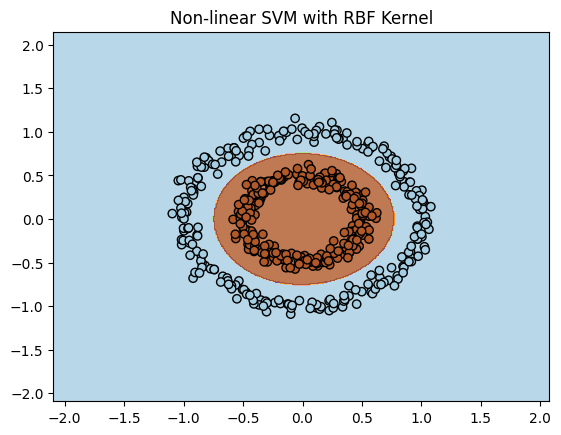

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Creating and Splitting the Dataset
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating and Training the Non-Linear SVM Model
svm = SVC(kernel='rbf', C=1, gamma=0.5)  # RBF kernel allows learning circular boundaries
svm.fit(X_train, y_train)

# Making Predictions and Evaluating the Model
y_pred = svm.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualizing the Decision Boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title("Non-linear SVM with RBF Kernel")
    plt.show()

# Plot the decision boundary
plot_decision_boundary(X, y, svm)

## <br>Non linear SVM for Radial Curve Pattern

Accuracy: 1.00


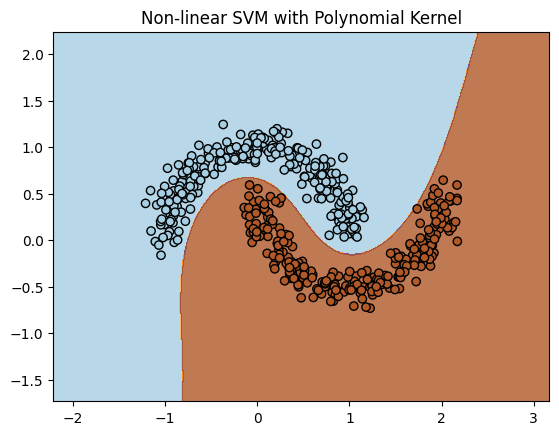

In [4]:
from sklearn.datasets import make_moons

# Creating and Splitting the Dataset
X, y = make_moons(n_samples=500, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Creating and Training the SVM with Polynomial Kernel
svm_poly = SVC(kernel='poly', degree=3, C=1, coef0=1)  # degree and coef0 control the curve of the boundary
svm_poly.fit(X_train, y_train)

# Making Predictions and Evaluating the Model
y_pred = svm_poly.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Visualizing the Decision Boundary
def plot_decision_boundary(X, y, model):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01),
                         np.arange(y_min, y_max, 0.01))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
    plt.title("Non-linear SVM with Polynomial Kernel")
    plt.show()
    
plot_decision_boundary(X, y, svm_poly)

## Linear vs Non-Linear SVM

| | **Linear SVM** | **Non-Linear SVM** |
|---|---|---|
| **Boundary** | Straight line / hyperplane | Curved / complex shape |
| **Data** | Linearly separable | Non-linearly separable |
| **Kernel** | Linear (or none) | RBF, Polynomial, Sigmoid |
| **Speed** | Faster | More compute-intensive |
| **Example** | Spam detection | Image / handwriting recognition |

### Applications of Non-Linear SVM

- **Image classification** — handwritten digits (MNIST), object recognition
- **Medical diagnosis** — tumor classification from non-linear patient data
- **NLP** — sentiment analysis, spam filtering
- **Bioinformatics** — gene expression, protein classification
- **Fraud detection** — spotting unusual patterns in transactions
- **Speech recognition** — separating voice signals with curved boundaries